In [1]:
# RRCP (03/08/2026): Notebook de Arbol de Decision
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Carga de datos.
df_partidos = pd.read_csv("../data/partidos_cebollitas_30072026.csv")
df_partidos.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   fecha_partido           100 non-null    str  
 1   equipo_local            100 non-null    str  
 2   equipo_visitante        100 non-null    str  
 3   goles_local             100 non-null    int64
 4   goles_visitante         100 non-null    int64
 5   posesion_local (%)      100 non-null    int64
 6   posesion_visitante (%)  100 non-null    int64
 7   tiros_arco_local        100 non-null    int64
 8   tiros_arco_visitante    100 non-null    int64
 9   estadio                 100 non-null    str  
dtypes: int64(6), str(4)
memory usage: 7.9 KB


In [3]:
# Features: Nuevas variables que ayudarán al modelo.
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']
df_partidos['diferencia_posesion'] = df_partidos['posesion_local (%)'] - df_partidos['posesion_visitante (%)']
df_partidos['eficiencia_tiros_local'] = df_partidos['goles_local'] / (df_partidos['tiros_arco_local'] + 1e-5)
df_partidos['eficiencia_tiros_visitante'] = df_partidos['goles_visitante'] / (df_partidos['tiros_arco_visitante'] + 1e-5)
df_partidos['local_es_cebollitas'] = (df_partidos['equipo_local'] == 'Cebollitas FC').astype(int)
df_partido = pd.get_dummies(df_partidos, columns=['estadio'], drop_first = True)

In [4]:
# Elegimos las variables más informativas
features = ['posesion_local (%)', 'tiros_arco_local', 'diferencia_posesion',
            'eficiencia_tiros_local', 'eficiencia_tiros_visitante',
            'local_es_cebollitas'] + [col for col in df_partidos.columns if col.startswith("estadio_")]

X = df_partidos[features]
y = df_partidos['diferencia_goles']

In [5]:
# Separar en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Entrenamos el modelo Random Forest
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
# Hacer predicciones
y_pred_rf = modelo_rf.predict(X_test)

In [10]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Métricas de evaluación
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R2: {r2_rf:.2f}")

import numpy as np

RMSE: 1.04
MAE: 0.75
R2: 0.77


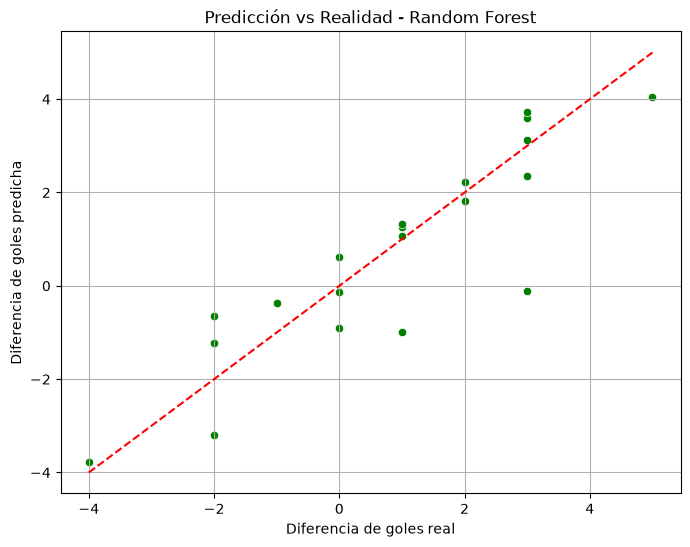

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y = y_pred_rf, color = 'green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Diferencia de goles real")
plt.ylabel("Diferencia de goles predicha")
plt.title("Predicción vs Realidad - Random Forest")
plt.grid(True)
plt.show()